# 02 : Exploration des données (EDA)

**Entrée** : base `data/openpayments.sqlite` (notebook 01)
**Tables** : `payments` (~186 000 paiements bruts) et `hcp_features` (~5 700 profils de professionnels de santé)

---

## Objectif

Comprendre la donnée avant de modéliser : structure, distributions, valeurs extrêmes, natures de paiement, spécialités, laboratoires, et surtout la **cible de rétention**. On cherche des faits actionnables et des pièges (déséquilibre, asymétrie des montants) qui guideront le notebook de modélisation.

## 0. Chargement

In [1]:
import sqlite3, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().parent / "data").exists() else pathlib.Path.cwd()
DB_PATH = ROOT / "data" / "openpayments.sqlite"
with sqlite3.connect(DB_PATH) as con:
    payments = pd.read_sql("SELECT * FROM payments", con)
    hcp = pd.read_sql("SELECT * FROM hcp_features", con)
print("payments:", payments.shape, "| hcp_features:", hcp.shape)

payments: (186223, 9) | hcp_features: (5707, 14)


## 1. Aperçu général

Les trois outils standards de toute EDA : `head()` pour vérifier que la donnée a du sens, `describe()` pour repérer les valeurs extrêmes, et le comptage des types.

In [2]:
display(hcp.head())
hcp[["n_payments", "total_amount", "mean_amount", "n_manufacturers", "retenu"]].describe().round(2)

,covered_recipient_profile_id,n_payments,total_amount,mean_amount,n_manufacturers,n_natures,specialty,state,share_food,share_travel,share_consulting,share_speaker,share_education,retenu
0,1000304,10,176.44,17.644000,2,1,Allopathic & Osteopathic Physicians,WV,1.000000,0.000000,0.0,0.0,0.0,1
1,1001595,14,2533.93,180.995000,3,2,Allopathic & Osteopathic Physicians,WV,0.571429,0.428571,0.0,0.0,0.0,1
2,100261,78,1199.01,15.371923,17,1,Allopathic & Osteopathic Physicians,WV,1.000000,0.000000,0.0,0.0,0.0,1
3,1002721,55,896.83,16.306000,17,1,Allopathic & Osteopathic Physicians,WV,1.000000,0.000000,0.0,0.0,0.0,1
4,1003026,6,108.56,18.093333,5,1,Allopathic & Osteopathic Physicians,WV,1.000000,0.000000,0.0,0.0,0.0,1


,n_payments,total_amount,mean_amount,n_manufacturers,retenu
count,5707.00,5707.00,5707.00,5707.00,5707.00
mean,15.81,1359.23,82.81,4.27,0.73
std,32.78,11097.35,1271.84,5.02,0.44
min,1.00,0.75,0.75,1.00,0.00
25%,1.00,36.76,16.27,1.00,0.00
50%,4.00,121.64,19.60,2.00,1.00
75%,15.00,405.96,38.05,5.00,1.00
max,499.00,338210.38,92283.00,46.00,1.00


> **Observations.** L'unité est le professionnel de santé. Les variables d'engagement sont **très asymétriques** : la plupart des HCP reçoivent peu de paiements et de petits montants, une minorité en concentre beaucoup. La cible `retenu` a une moyenne autour de 0,73 (rappel : 73 % de rétention).

## 2. Distribution des montants et de l'engagement

Les montants et le nombre de paiements sont fortement asymétriques (loi de puissance typique de ce type de données). On tronque au 99e centile pour la lisibilité.

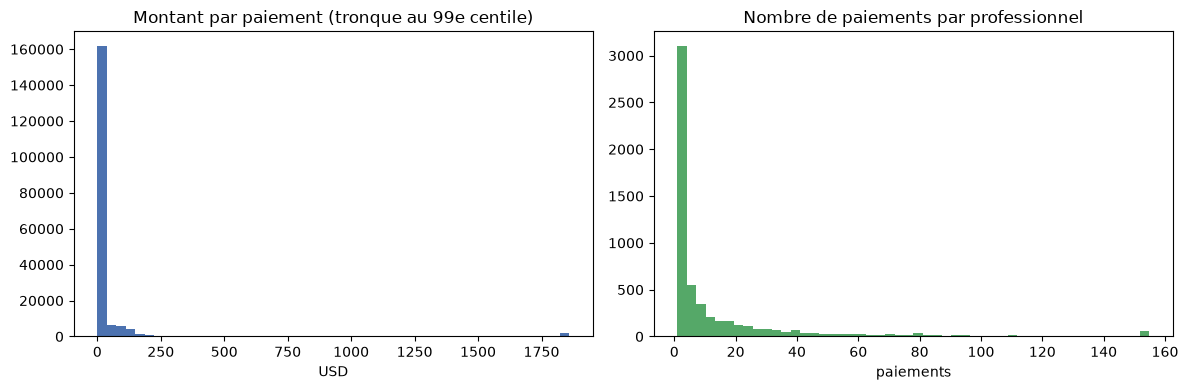

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
m = payments["total_amount_of_payment_usdollars"].clip(upper=payments["total_amount_of_payment_usdollars"].quantile(0.99))
ax[0].hist(m, bins=50, color="#4C72B0"); ax[0].set_title("Montant par paiement (tronque au 99e centile)"); ax[0].set_xlabel("USD")
ax[1].hist(hcp["n_payments"].clip(upper=hcp["n_payments"].quantile(0.99)), bins=50, color="#55A868")
ax[1].set_title("Nombre de paiements par professionnel"); ax[1].set_xlabel("paiements")
plt.tight_layout(); plt.show()

> **Observations.** Distributions en forte asymétrie : une longue traine de gros paiements et de HCP très sollicites. La standardisation (StandardScaler) dans le modele est donc justifiee.

## 3. Natures de paiement, spécialités et laboratoires

Qui paie, à qui, et pour quoi ? On regarde les trois répartitions les plus utiles au métier.

C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_35900\2106938844.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(); plt.show()


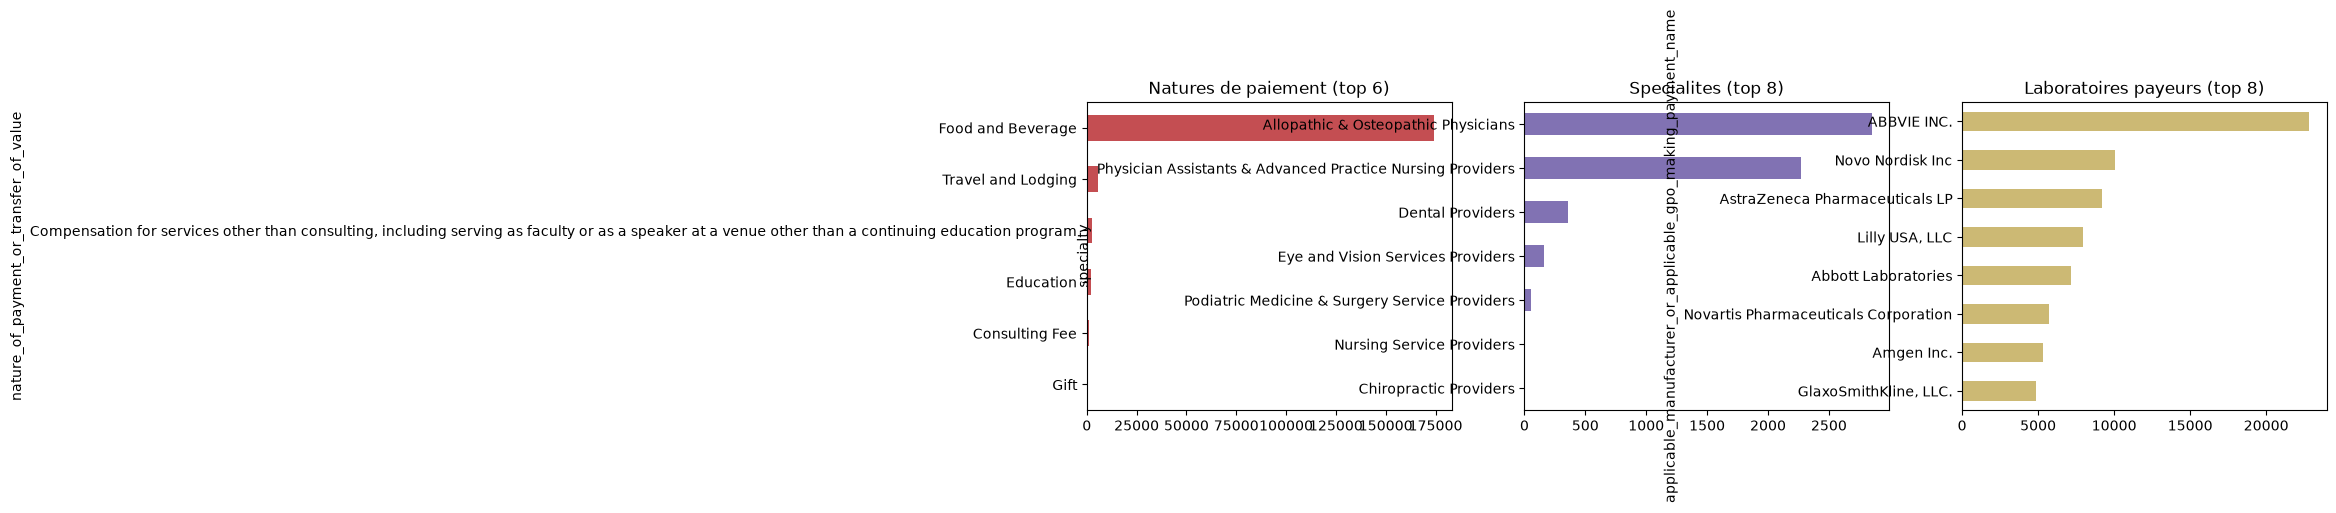

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
payments["nature_of_payment_or_transfer_of_value"].value_counts().head(6).plot.barh(ax=ax[0], color="#C44E52")
ax[0].set_title("Natures de paiement (top 6)"); ax[0].invert_yaxis()
hcp["specialty"].value_counts().head(8).plot.barh(ax=ax[1], color="#8172B3")
ax[1].set_title("Specialites (top 8)"); ax[1].invert_yaxis()
payments["applicable_manufacturer_or_applicable_gpo_making_payment_name"].value_counts().head(8).plot.barh(ax=ax[2], color="#CCB974")
ax[2].set_title("Laboratoires payeurs (top 8)"); ax[2].invert_yaxis()
plt.tight_layout(); plt.show()

> **Observations.** **Food and Beverage** (repas) domine de loin les natures de paiement. Les spécialités les plus représentées sont les médecins et les professions infirmières avancées (PA/IPA). Côté laboratoires, on voit apparaitre le probleme de **normalisation des noms** (ex. "ABBVIE INC." et "AbbVie Inc." comptés séparément).

## 4. La cible : rétention et lien avec l'engagement

On visualise l'équilibre de la cible, puis la rétention **en fonction de l'intensité d'engagement** (déciles du nombre de paiements) : c'est l'hypothèse centrale du projet.

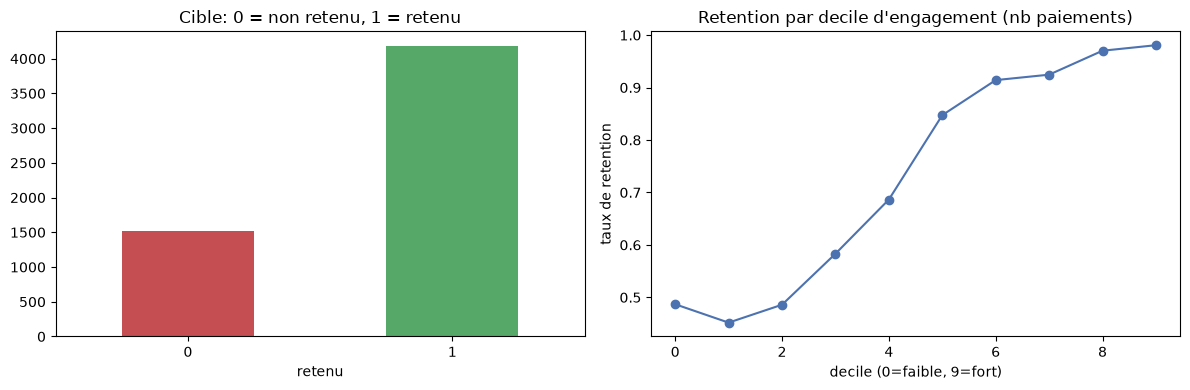

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hcp["retenu"].value_counts().sort_index().plot.bar(ax=ax[0], color=["#C44E52", "#55A868"])
ax[0].set_title("Cible: 0 = non retenu, 1 = retenu"); ax[0].set_xticklabels(["0", "1"], rotation=0)

hcp["decile_engagement"] = pd.qcut(hcp["n_payments"].rank(method="first"), 10, labels=False)
hcp.groupby("decile_engagement")["retenu"].mean().plot(ax=ax[1], marker="o", color="#4C72B0")
ax[1].set_title("Retention par decile d'engagement (nb paiements)"); ax[1].set_xlabel("decile (0=faible, 9=fort)"); ax[1].set_ylabel("taux de retention")
plt.tight_layout(); plt.show()

> **Observations.** La cible est **déséquilibrée** (~73 % de retenus). Surtout, la rétention **croît nettement avec l'engagement** : les HCP du décile le plus sollicité sont presque tous retenus, ceux du décile le plus faible décrochent beaucoup plus. C'est exactement le signal que le modèle exploitera.

## 5. Corrélations entre variables numériques

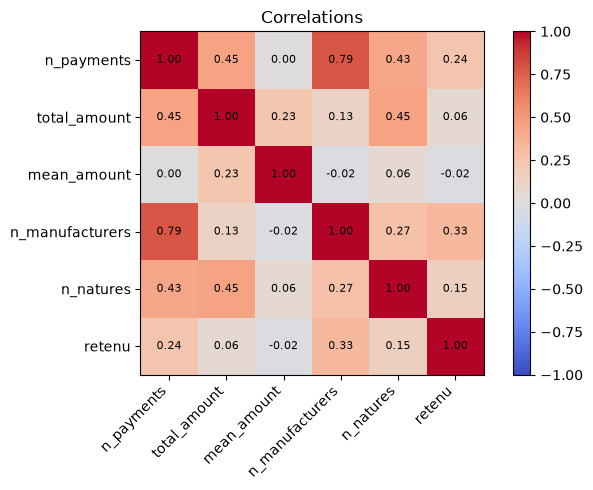

In [6]:
num = ["n_payments", "total_amount", "mean_amount", "n_manufacturers", "n_natures", "retenu"]
corr = hcp[num].corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha="right")
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.title("Correlations"); plt.tight_layout(); plt.show()

> **Observations.** `n_payments`, `total_amount` et `n_manufacturers` sont **corrélés entre eux** (facettes d'une même intensité d'engagement) et **positivement liés à `retenu`**. `mean_amount` est plus indépendant. Cela confirme le choix des variables et annonce les moteurs du modèle (notebook 03).